In [7]:
import numpy as np
def jacobi(A, b, x0, tol, max_iterations=100):
    n = len(b)
    x = x0.copy()
    e=[] #error
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        # Check for convergence
        e.append(np.linalg.norm(x_new-x, ord=np.inf))#error
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k,e
        x = x_new
    return x, max_iterations,e

In [8]:
import numpy as np
def gauss_seidel(A, b, x0, tol, max_iterations=100):
    n = len(b)
    x = x0.copy()
    e= [] #error
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
# Check for convergence
        e.append (np.linalg.norm(x_new-x, ord= np.inf))#saving error
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k, e 
        x = x_new
    return x, max_iterations,e

In [9]:
import numpy as np

A= np.array ([[3,-0.1,-0.2],
            [0.1,7,-0.3],
            [0.3,-0.2,10]])
b= np.array ([7.85,-19.3,71.4])
x0= np.zeros_like(b,dtype=float)


tolerance of 1e-9: solution=array([ 3. , -2.5,  7. ]), iterations=8
tolerance of 1e-6: solution=array([ 3. , -2.5,  7. ]), iterations=6
tolerance of 1e-3: solution=array([ 3.0000225 , -2.50000266,  6.99998104]), iterations=3


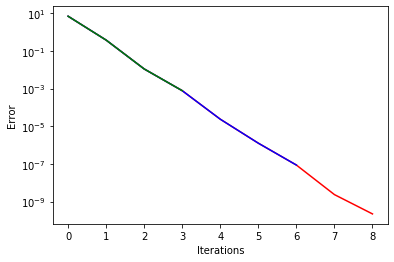

In [10]:
#jacobi plotting
import matplotlib.pyplot as plt
solution, iterations, error= jacobi(A,b,x0,tol=1e-9)
print (f"tolerance of 1e-9: {solution=}, {iterations=}")
plt.plot(np.arange(0,len(error)), error, 'r')

solution, iterations, error= jacobi(A,b,x0,tol=1e-6)
print (f"tolerance of 1e-6: {solution=}, {iterations=}")
plt.plot(np.arange(0,len(error)), error, 'b')

solution, iterations, error= jacobi(A,b,x0,tol=1e-3)
print (f"tolerance of 1e-3: {solution=}, {iterations=}")
plt.plot(np.arange(0,len(error)), error, 'g')
plt.xlabel("Iterations")
plt.yscale("log")
plt.ylabel("Error")

plt.show()


tolerance of 1e-9: solution=array([ 3. , -2.5,  7. ]), iterations=6
tolerance of 1e-6: solution=array([ 3. , -2.5,  7. ]), iterations=4
tolerance of 1e-3: solution=array([ 3.00000035, -2.50000004,  6.99999999]), iterations=3


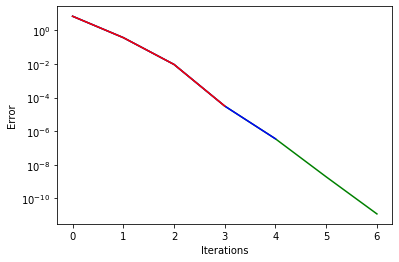

In [11]:
#gauss-siedel
import matplotlib.pyplot as plt

solution, iterations, error= gauss_seidel(A,b,x0,tol=1e-9)
print (f"tolerance of 1e-9: {solution=}, {iterations=}")
plt.plot(np.arange(0,len(error)), error, 'g')
    
solution, iterations, error= gauss_seidel(A,b,x0,tol=1e-6)
print (f"tolerance of 1e-6: {solution=}, {iterations=}")
plt.plot(np.arange(0,len(error)), error, 'b')

solution, iterations, error= gauss_seidel(A,b,x0,tol=1e-3)
print (f"tolerance of 1e-3: {solution=}, {iterations=}")
plt.plot(np.arange(0,len(error)), error, 'r')
plt.xlabel("Iterations")
plt.yscale("log")
plt.ylabel("Error")

plt.show()


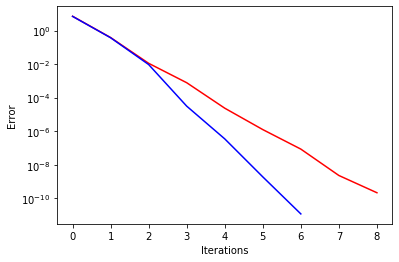

In [15]:
import matplotlib.pyplot as plt
#JACOBIAN IN RED
solution, iterations, error= jacobi(A,b,x0,tol=1e-9)
plt.plot(np.arange(0,len(error)), error, 'r')

#GAUSS IN BLUE
solution, iterations, error= gauss_seidel(A,b,x0,tol=1e-9)
plt.plot(np.arange(0,len(error)), error, 'b')

plt.xlabel("Iterations")
plt.yscale("log")
plt.ylabel("Error")
plt.show()

As tolerance decreases the number of iterations required to converge will increase, showing an inverse relationship. As the tolereance decreases, the error will decrease. The jacobi method takes more iterations to run while the gauss-siedel method takes less iterations to run. Yet despite these differences in iteration, the decrease in tolereance will cause the number of iterations to increase across both methods. You can see the difference in the error in the final graph where Gauss-Siedel which converges faster, beats the Jacobi method.